In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sm

In [4]:
year = [2017, 2017, 2017, 2017, 2017, 2017, 2017, 2017, 2017, 2017, 2017, 2017, 2016, 2016, 2016, 2016, 2016, 2016, 2016, 2016, 2016]
interest_rate = [2.75, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.25, 2.25, 2.25, 2.0, 2.0, 2.0, 1.75, 1.75, 1.75, 1.75, 1.75, 1.75, 1.75, 1.75]
month = [12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 12, 11, 10, 9, 8, 7, 6, 5, 4]
unemployment_rate = [5.3, 5.3, 5.3, 5.3, 5.4, 5.6, 5.5, 5.5, 5.5, 5.6, 5.7, 5.9, 6.0, 5.9, 5.8, 6.1, 6.2, 6.1, 6.1, 6.1, 5.9]
index_price = [1464, 1394, 1357, 1293, 1256, 1254, 1234, 1195, 1159, 1167, 1130, 1075, 1047, 965, 943, 958, 971, 949, 884, 866, 876]

df_index = pd.DataFrame({"year" : year, "interest_rate" : interest_rate, "month" : month, "unemployment_rate" : unemployment_rate, "index_price" : index_price})

In [5]:
df_index.head()

,year,interest_rate,month,unemployment_rate,index_price
0,2017,2.75,12,5.3,1464
1,2017,2.50,11,5.3,1394
2,2017,2.50,10,5.3,1357
3,2017,2.50,9,5.3,1293
4,2017,2.50,8,5.4,1256


In [6]:
# drop unnecessary columns
df_index.drop(columns=["year", "month"], axis=1, inplace=True)

In [7]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [8]:
df_index.isnull().sum()

,0
interest_rate,0
unemployment_rate,0
index_price,0


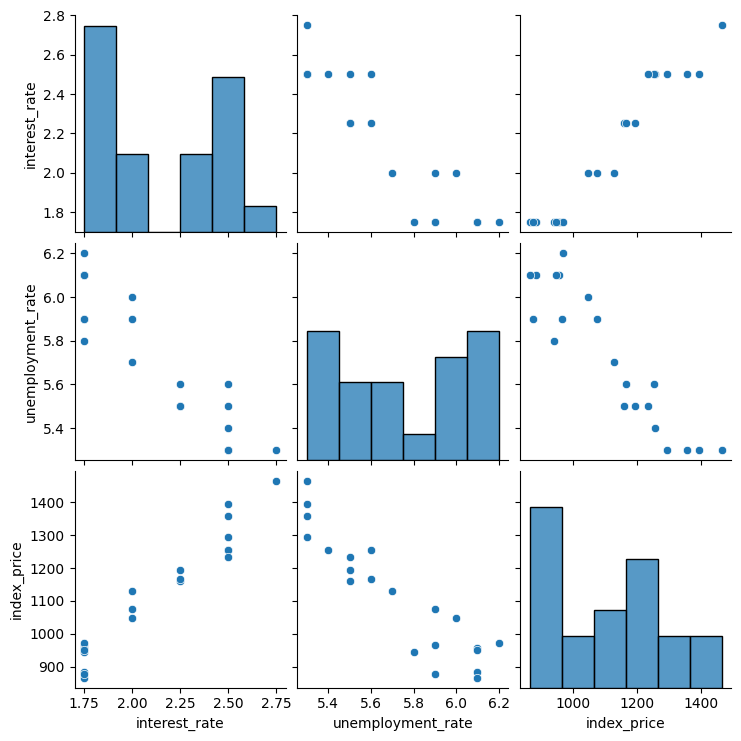

In [9]:
# visualization
sns.pairplot(df_index)

In [10]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.919655,0.967423
unemployment_rate,-0.919655,1.000000,-0.918204
index_price,0.967423,-0.918204,1.000000


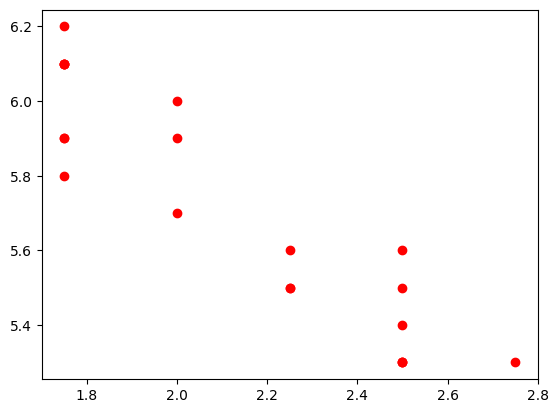

In [11]:
plt.scatter(df_index["interest_rate"], df_index["unemployment_rate"], color='r')

In [12]:
#independent and dependent features
X = df_index[["interest_rate", "unemployment_rate"]]
Y = df_index.iloc[:, -1]

In [13]:
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [14]:
Y.head()

,index_price
0,1464
1,1394
2,1357
3,1293
4,1256


In [15]:
# train test split
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.25, random_state=42)

In [16]:
x_train.head()

,interest_rate,unemployment_rate
11,2.00,5.9
3,2.50,5.3
18,1.75,6.1
16,1.75,6.2
13,1.75,5.9


<Axes: xlabel='interest_rate', ylabel='index_price'>

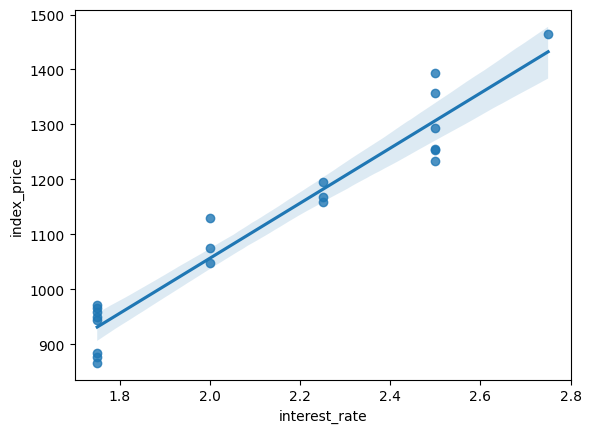

In [17]:
sns.regplot(x=df_index["interest_rate"], y=df_index["index_price"])

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

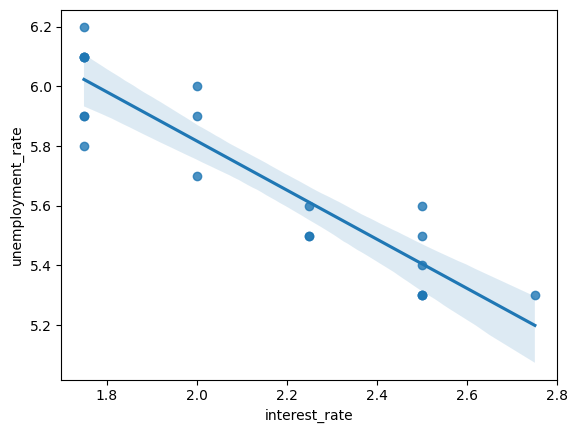

In [18]:
sns.regplot(x=df_index["interest_rate"], y=df_index["unemployment_rate"])

In [19]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [20]:
x_train

array([[-0.21566555,  0.52961099],
       [ 1.40182605, -1.54277985],
       [-1.02441135,  1.22040794],
       [-1.02441135,  1.56580642],
       [-1.02441135,  0.52961099],
       [ 1.40182605, -1.54277985],
       [ 0.59308025, -0.50658443],
       [-1.02441135,  0.52961099],
       [ 1.40182605, -1.19738138],
       [-0.21566555,  0.87500947],
       [ 0.59308025, -0.8519829 ],
       [-0.21566555, -0.16118595],
       [-1.02441135,  0.18421252],
       [-1.02441135,  1.22040794],
       [ 1.40182605, -0.8519829 ]])

In [21]:
#training model
regression = LinearRegression()
regression.fit(x_train, y_train)

LinearRegression()

In [22]:
#cross validation
validation_score = cross_val_score(regression, x_train, y_train, scoring="neg_mean_squared_error", cv=3)

In [23]:
np.mean(validation_score)

np.float64(-2947.557868172747)

In [24]:
#prediction
y_pred = regression.predict(x_test)

In [25]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

mse, mae, rmse

(2499.088833995056, 43.27254585407411, np.float64(49.99088750957574))

In [26]:
score = r2_score(y_test, y_pred)
score

0.9357597409289515

In [27]:
1 - (((1 - score) * (len(y_test) - 1)) / ((len(y_test) - x_test.shape[1] - 1)))

0.8929329015482526

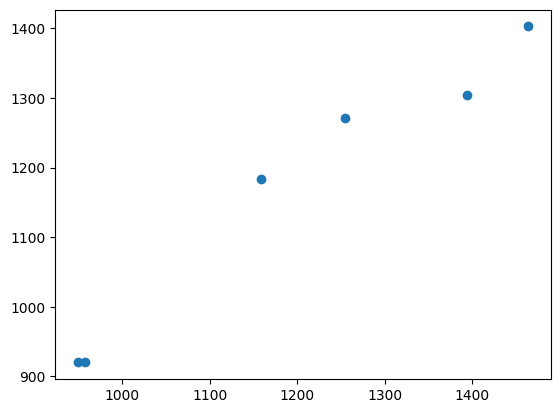

In [28]:
plt.scatter(y_test, y_pred)

In [29]:
residuals = y_test - y_pred

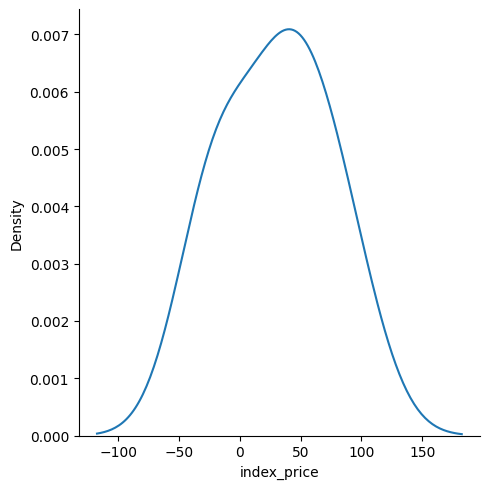

In [30]:
sns.displot(residuals, kind='kde')

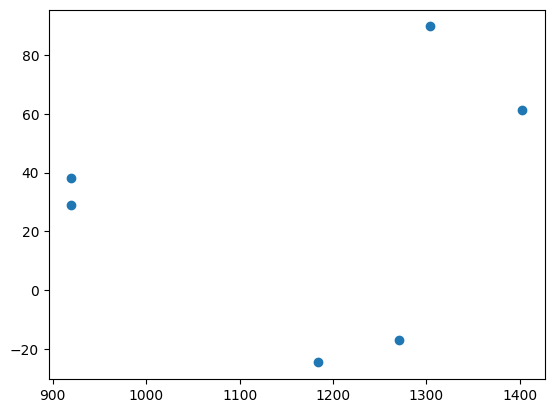

In [31]:
plt.scatter(y_pred, residuals)

In [32]:
model = sm.OLS(y_train, x_train).fit()

In [33]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.019
Model:                            OLS   Adj. R-squared (uncentered):             -0.132
Method:                 Least Squares   F-statistic:                             0.1270
Date:                Fri, 30 Jan 2026   Prob (F-statistic):                       0.882
Time:                        11:48:49   Log-Likelihood:                         -126.12
No. Observations:                  15   AIC:                                      256.2
Df Residuals:                      13   BIC:                                      257.7
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1           121.7021    725.723      0.168      0.869   -1446.128    1689.532
x2           -32.2321    725.723     -0.044      0.965   -1600.062    1535.598
==============================================================================
Omnibus:                        1.615   Durbin-Watson:                   0.002
Prob(Omnibus):                  0.446   Jarque-Bera (JB):                0.874
Skew:                           0.085   Prob(JB):                        0.646
Kurtosis:                       1.830   Cond. No.                         4.61
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [34]:
regression.coef_

array([121.70211337, -32.23210751])